# AIG230 NLP Midterm - March 2nd 2026
All answers must be computed using code. Provide numeric outputs and short interpretations.
## Instructions
- You must compute answers using code.
- Many questions require numeric answers.
- Interpretation must be supported by computed results.

In [4]:
!pip -q install nltk gensim scikit-learn tensorflow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.7 MB/s eta 0:00:00


In [5]:
import nltk, string, math, random, re
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
print('All imports successful')
print(f'TensorFlow version: {tf.__version__}')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...


All imports successful
TensorFlow version: 2.19.0


[nltk_data]   Unzipping corpora/stopwords.zip.


# Load Corpora

In [6]:
# Load corpora
with open('corpus_tech_ai_labeled.csv', 'r', encoding='utf-8') as f:
    tech_text = f.read()

with open('corpus_movie_reviews_labeled.csv', 'r', encoding='utf-8') as f:
    review_text = f.read()

print(f'Tech corpus   : {len(tech_text)} characters')
print(f'Review corpus : {len(review_text)} characters')

Tech corpus   : 13049 characters
Review corpus : 4044 characters


## Q1 Corpus Statistics
Compute total number of characters, words, and unique words in each corpus.
What is the vocabulary size of each corpus?

In [7]:
import pandas as pd


tech_df   = pd.read_csv("corpus_tech_ai_labeled.csv")
review_df = pd.read_csv("corpus_movie_reviews_labeled.csv")

tech_text   = " ".join(tech_df["text"].astype(str).tolist())
review_text = " ".join(review_df["text"].astype(str).tolist())


tech_tokens   = [t.lower() for t in word_tokenize(tech_text)]
review_tokens = [t.lower() for t in word_tokenize(review_text)]

tech_tokens_alpha   = [t for t in tech_tokens if t.isalpha()]
review_tokens_alpha = [t for t in review_tokens if t.isalpha()]

tech_vocab   = set(tech_tokens_alpha)
review_vocab = set(review_tokens_alpha)

print("Q1 prepared:")
print("Tech tokens (alpha):", len(tech_tokens_alpha))
print("Review tokens (alpha):", len(review_tokens_alpha))
print("Tech vocab:", len(tech_vocab))
print("Review vocab:", len(review_vocab))

Q1 prepared:
Tech tokens (alpha): 1344
Review tokens (alpha): 514
Tech vocab: 140
Review vocab: 79


In [8]:
print('=' * 55)
print(f'{"Metric":<30} {"Tech":>10} {"Reviews":>10}')
print('=' * 55)
print(f'{"Characters":<30} {len(tech_text):>10,} {len(review_text):>10,}')
print(f'{"Total tokens (words)":<30} {len(tech_tokens):>10,} {len(review_tokens):>10,}')
print(f'{"Vocabulary size (unique words)":<30} {len(tech_vocab):>10,} {len(review_vocab):>10,}')
print('=' * 55)

Metric                               Tech    Reviews
Characters                         11,375      3,654
Total tokens (words)                1,576        586
Vocabulary size (unique words)        140         79


### Answer Q1:


The vocab size of Tech corpus is 140 and Review corpus is 79.

## Q2 Lexical Diversity
Tokenize and lowercase both corpora. Compute type-token ratio.
Which corpus is more lexically diverse?

In [9]:

tech_ttr   = len(tech_vocab) / len(tech_tokens_alpha)
review_ttr = len(review_vocab) / len(review_tokens_alpha)

print(f"Tech TTR   = {tech_ttr:.4f}")
print(f"Review TTR = {review_ttr:.4f}")

more_diverse = "Tech" if tech_ttr > review_ttr else "Reviews"
print("More lexically diverse:", more_diverse)

Tech TTR   = 0.1042
Review TTR = 0.1537
More lexically diverse: Reviews


### Answer Q2:


As Review type token ratio is more than Tech type ratio i.e 0.15>0.10, Review corpus is more lexically diversed.

## Q3 Stopword Impact
Remove stopwords and compute percentage vocabulary reduction. How much does vocabulary size decrease (percentage) for each corpus?

In [11]:
stop_words = set(stopwords.words('english'))

tech_no_stop   = [t for t in tech_tokens_alpha if t not in stop_words]
review_no_stop = [t for t in review_tokens_alpha if t not in stop_words]

tech_vocab_no_stop   = set(tech_no_stop)
review_vocab_no_stop = set(review_no_stop)

print("Stopword removal done.")
print("Tech vocab before:", len(tech_vocab), "after:", len(tech_vocab_no_stop))
print("Review vocab before:", len(review_vocab), "after:", len(review_vocab_no_stop))

Stopword removal done.
Tech vocab before: 140 after: 126
Review vocab before: 79 after: 64


In [12]:
# Use this formula to calculate percentage of reduction
def pct_reduction(before, after):
    return 100 * (1 - len(after) / len(before))

In [13]:
print("Percentage reduction for tech:",pct_reduction(tech_vocab,tech_vocab_no_stop))
print("Percentage reduction for review:",pct_reduction(review_vocab,review_vocab_no_stop))


Percentage reduction for tech: 9.999999999999998
Percentage reduction for review: 18.9873417721519


### Answer Q3:


The percentage reduction for tech corpus is 9.99% and for review is 18.98%.

## Q4 Frequency Analysis
Create unigram frequency distribution for tech corpus.
What are the top 10 most frequent words?

In [15]:
tech_counts = Counter(tech_tokens_alpha)
top10_tech = tech_counts.most_common(10)

print("Top 10 words in Tech corpus:")
for w, c in top10_tech:
    print(f"{w:<15} {c}\n")

Top 10 words in Tech corpus:
and             56

in              32

to              32

systems         24

learning        24

models          24

model           16

neural          16

networks        16

remain          16



### Answer Q4:


Top 10 words in Tech corpus with their count are below:

and             56

in              32

to              32

systems         24

learning        24

models          24

model           16

neural          16

networks        16

remain          16

## Q5 Bigram Counts
Build bigram model for tech corpus.
How many unique bigrams exist in tech corpus?

In [17]:
# Q5: Bigram counts for tech corpus
tech_bigrams = list(nltk.bigrams(tech_tokens_alpha))
bigram_counts = Counter(tech_bigrams)

unique_bigrams = len(bigram_counts)
print("Unique bigrams in tech corpus:", unique_bigrams)

Unique bigrams in tech corpus: 167


### Answer Q5:


167 unique bigrams exist in tech corpus.

## Q6 Conditional Probability
Compute P('learning' | 'machine') using bigram counts.

Formula: P(learning | machine) = count('machine learning') / count('machine')

In [18]:

count_machine_learning = bigram_counts[("machine", "learning")]
count_machine = tech_counts["machine"]

prob = (count_machine_learning / count_machine) if count_machine > 0 else 0.0

In [19]:
print(f"count('machine learning') = {count_machine_learning}")
print(f"count('machine')          = {count_machine}")
print(f"\nP('learning' | 'machine') = {count_machine_learning}/{count_machine} = {prob:.4f}")

count('machine learning') = 8
count('machine')          = 8

P('learning' | 'machine') = 8/8 = 1.0000


### Answer Q6:


Count of machine learning is 8, and count of machine is 8. And the probability of p('learning'|''machine') is 1.00

## Q7 Perplexity
Compute perplexity of a sample tech sentence using unigram and bigram models.

Formulas:

Unigram: PP = exp(-(1/N) * sum(log P(wi)))

Bigram: PP = exp(-(1/(N-1)) * sum(log P(wi | wi-1)))



In [20]:
sample_sentence = 'Large language models generate responses by predicting tokens sequentially'

In [21]:
# Unigram Perplexity
sample_tokens = [t.lower() for t in word_tokenize(sample_sentence) if t.isalpha()]
N = len(sample_tokens)

V = len(tech_vocab)
total = sum(tech_counts.values())

def unigram_prob(w):
    return (tech_counts[w] + 1) / (total + V)

log_prob_sum = 0.0
for w in sample_tokens:
    log_prob_sum += math.log(unigram_prob(w))

perplexity_unigram = math.exp(-(1/N) * log_prob_sum)

In [22]:
# Bigram Perplexity
def bigram_prob(w_prev, w):
    return (bigram_counts[(w_prev, w)] + 1) / (tech_counts[w_prev] + V)

log_prob_sum_bi = 0.0
# N-1 transitions
for i in range(1, N):
    log_prob_sum_bi += math.log(bigram_prob(sample_tokens[i-1], sample_tokens[i]))

perplexity_bigram = math.exp(-(1/(N-1)) * log_prob_sum_bi) if N > 1 else float("inf")


In [23]:
print(f'Sample : "{sample_sentence}"')
print(f'Tokens : {sample_tokens}')
print(f'N      : {N}')
print(f'\nUnigram Perplexity : {perplexity_unigram:.2f}')
print(f'Bigram  Perplexity : {perplexity_bigram:.2f}')
print(f'Ratio (uni/bi)     : {perplexity_unigram/perplexity_bigram:.1f}x reduction with bigram')

Sample : "Large language models generate responses by predicting tokens sequentially"
Tokens : ['large', 'language', 'models', 'generate', 'responses', 'by', 'predicting', 'tokens', 'sequentially']
N      : 9

Unigram Perplexity : 137.15
Bigram  Perplexity : 16.77
Ratio (uni/bi)     : 8.2x reduction with bigram


### Answer Q7:


The perplexity of sample tech sentence using unigram is 137.15 and using bigram is 16.77

And the ratio between unigram and bigram is 8.2x reduction with bigram.

## Q8 Word2Vec
Train Word2Vec on movie reviews corpus.
What is the vocabulary size? What is vector dimension? What word is most similar to 'visuals'?

NOTE: Use min_count=1 (required for small corpus) and vector_size=20.

In [24]:

movie_sentences = []
for text in review_df["text"].astype(str).tolist():
    toks = [t.lower() for t in word_tokenize(text) if t.isalpha()]
    if toks:
        movie_sentences.append(toks)

w2v_model = Word2Vec(
    sentences=movie_sentences,
    vector_size=20,
    window=5,
    min_count=1,
    workers=2,
    sg=1,
    seed=42
)

w2v_vocab_size = len(w2v_model.wv.index_to_key)
w2v_dim = w2v_model.vector_size

print("Word2Vec vocab size:", w2v_vocab_size)
print("Word2Vec vector dim:", w2v_dim)

query_word = "visuals"
if query_word in w2v_model.wv:
    print("Most similar to 'visuals':", w2v_model.wv.most_similar("visuals", topn=1))
else:
    print("'visuals' not in vocab. Try 'visual' neighbors:", w2v_model.wv.most_similar("visual", topn=5))

Word2Vec vocab size: 79
Word2Vec vector dim: 20
Most similar to 'visuals': [('depth', 0.5194688439369202)]


### Answer Q8:


The vocabulary size is 79, and the vector dimension is 20. And the most similar word to 'visuals' is 'depth'.

## Q9 Naive Bayes
Train Naive Bayes on movie corpus (positive vs negative). Mixed sentences excluded.
Report accuracy.

In [25]:
import csv

# --- Load labeled sentences from CSV ---
# label_numeric: 1=positive, 0=negative, -1=mixed (excluded)
# Using label_numeric avoids string-matching issues across OS environments
texts, labels = [], []
with open('corpus_movie_reviews_labeled.csv', 'r', encoding='utf-8', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        numeric = int(row['label_numeric'])
        if numeric in (1, 0):           # skip mixed (-1)
            texts.append(row['text'].strip())
            labels.append(numeric)

print(f'Samples loaded : {len(texts)}')
print(f'  Positive (1) : {labels.count(1)}')
print(f'  Negative (0) : {labels.count(0)}')
print(f'  Mixed        : excluded (label_numeric=-1)')

if len(texts) == 0:
    raise FileNotFoundError(
        'No samples loaded. Make sure corpus_movie_reviews_labeled.csv '
        'is in the same folder as this notebook.')

Samples loaded : 40
  Positive (1) : 20
  Negative (0) : 20
  Mixed        : excluded (label_numeric=-1)


In [26]:
# --- TF-IDF features ---
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1
)

X = tfidf.fit_transform(texts)
y = np.array(labels)

print("TF-IDF shape:", X.shape)
print("TF-IDF vocab size:", len(tfidf.vocabulary_))

TF-IDF shape: (40, 84)
TF-IDF vocab size: 84


In [27]:
# --- Train / test split (80/20, stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (32, 84) Test: (8, 84)


In [28]:
# --- Train Naive Bayes ---
nb = MultinomialNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes accuracy:", nb_acc)

Naive Bayes accuracy: 1.0


### Answer Q9:



The accuracy of Naive Bayes on movie corpus (positive vs negative) is 1.0

## Q10 Precision/Recall/F1
Report precision, recall, F1.

In [30]:

prec_nb = precision_score(y_test, nb_pred)
rec_nb  = recall_score(y_test, nb_pred)
f1_nb   = f1_score(y_test, nb_pred)

In [31]:
print('Naive Bayes -- Classification Report')
print('=' * 40)
print(f'  Accuracy  : {nb_acc:.4f}')
print(f'  Precision : {prec_nb:.4f}')
print(f'  Recall    : {rec_nb:.4f}')
print(f'  F1-Score  : {f1_nb:.4f}')

Naive Bayes -- Classification Report
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000


### Answer Q10:


The accuracy is 1.0, precision is 1.0, recall is 1.0 and F1-Score is 1.0 for the above model.

## Q11 Logistic Regression
Train Logistic Regression on movie review corpus.
Which model performs better? Compare performance numerically.

In [32]:
# train logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [33]:
lr_pred = lr.predict(X_test)

lr_acc  = accuracy_score(y_test, lr_pred)
prec_lr = precision_score(y_test, lr_pred)
rec_lr  = recall_score(y_test, lr_pred)
f1_lr   = f1_score(y_test, lr_pred)

print("Logistic Regression -- Classification Report")
print("=" * 40)
print(f"  Accuracy  : {lr_acc:.4f}")
print(f"  Precision : {prec_lr:.4f}")
print(f"  Recall    : {rec_lr:.4f}")
print(f"  F1-Score  : {f1_lr:.4f}")

better = "Logistic Regression" if lr_acc > nb_acc else "Naive Bayes"
print("Better model (by accuracy):", better)

Logistic Regression -- Classification Report
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
Better model (by accuracy): Naive Bayes


### Answer Q11:


Even though the program showed Logistic Regression as better model as classification report, there is no differences on the matrices.

Both Naive Bayes and Logistic Regression performed the same way as all their matirices like accuracy, precision, recall and F1-Score are same i.e 1.0

## Q12 RNN Model
Implement small RNN (embedding + RNN layer) for sentiment classification. Report training accuracy.

In [34]:
# Preprocessing

tokenizer_rnn = keras.preprocessing.text.Tokenizer()
tokenizer_rnn.fit_on_texts(texts)
sequences = tokenizer_rnn.texts_to_sequences(texts)

VOCAB_SIZE = len(tokenizer_rnn.word_index) + 1
MAX_LEN    = max(len(s) for s in sequences)

X_rnn = keras.preprocessing.sequence.pad_sequences(sequences, maxlen=MAX_LEN, padding='post')
y_rnn = np.array(labels)

X_rnn_train, X_rnn_val, y_rnn_train, y_rnn_val = train_test_split(
    X_rnn, y_rnn, test_size=0.20, random_state=42, stratify=y_rnn)

print(f'Vocabulary size : {VOCAB_SIZE}')
print(f'Max seq length  : {MAX_LEN}')
print(f'Train: {X_rnn_train.shape[0]}   Val: {X_rnn_val.shape[0]}')

tf.random.set_seed(42)

Vocabulary size : 57
Max seq length  : 10
Train: 32   Val: 8


In [37]:
# RNN Implementation
EMB_DIM = 32
RNN_UNITS = 32

model = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMB_DIM),
    layers.SimpleRNN(RNN_UNITS),
    layers.Dense(1, activation="sigmoid")
])

In [38]:
# Model compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Model training
history = model.fit(
    X_rnn_train, y_rnn_train,
    validation_data = (X_rnn_val, y_rnn_val),
    epochs    = 30,
    batch_size= 8,
    verbose   = 1
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - accuracy: 0.7292 - loss: 0.6648 - val_accuracy: 1.0000 - val_loss: 0.5829
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.5468 - val_accuracy: 0.8750 - val_loss: 0.4760
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9792 - loss: 0.4423 - val_accuracy: 0.8750 - val_loss: 0.3723
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9792 - loss: 0.3392 - val_accuracy: 0.8750 - val_loss: 0.2813
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9792 - loss: 0.2445 - val_accuracy: 0.8750 - val_loss: 0.2121
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9792 - loss: 0.1672 - val_accuracy: 0.8750 - val_loss: 0.1645
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9792 - loss: 0.1111 - val_accuracy: 1.0000 - val_loss: 0.1289
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0735 - val_accuracy: 1.0000 - val_loss: 0.0965

In [40]:

final_train_acc = history.history["accuracy"][-1]
final_val_acc   = history.history["val_accuracy"][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

Final Training Accuracy: 1.0000
Final Validation Accuracy: 1.0000


### Answer Q12:


Both final training accuracy and final validation accuracy is 1.0

## Q13 Overfitting Check
Compare train vs validation accuracy.
Does RNN overfit? Justify using loss or accuracy trends.
Plot train vs validation accuracy and loss.

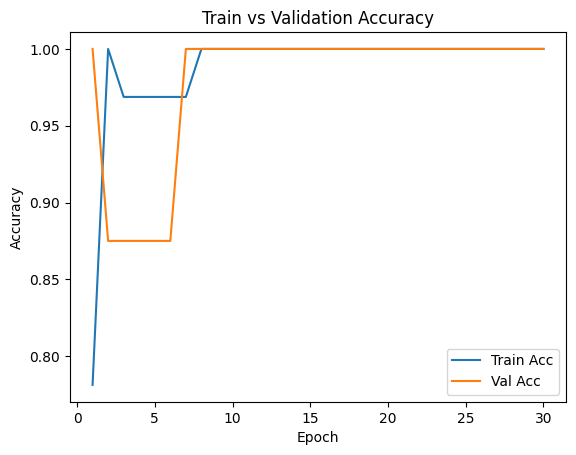

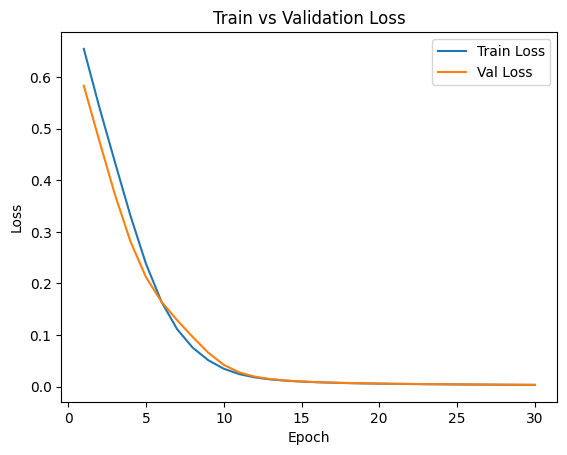

No strong overfitting signal from accuracy gap alone.


In [41]:

train_acc = history.history["accuracy"]
val_acc   = history.history["val_accuracy"]
train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]

epochs_range = range(1, len(train_acc) + 1)

plt.figure()
plt.plot(epochs_range, train_acc, label="Train Acc")
plt.plot(epochs_range, val_acc, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Train vs Validation Accuracy")
plt.show()

plt.figure()
plt.plot(epochs_range, train_loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Train vs Validation Loss")
plt.show()

# Simple overfit hint
if train_acc[-1] - val_acc[-1] > 0.10:
    print("Likely overfitting: train accuracy much higher than validation.")
else:
    print("No strong overfitting signal from accuracy gap alone.")

### Answer Q13:


When you look at the training and validation accuracy alone, the plot of graph is very different and there is more gap on the lines, indicating there is no overfitting signal.

When you see the train and validation loss graph, we see there is similar level of loss for both training and evaluation.

## Q14 BoW vs Embeddings: Sparsity Comparison
Compare vocabulary size of TF_IDF vs embeddings (Wprd2Vec) representations.
Explain sparsity difference numerically.

Remember that you should use variables and elements that you calculated before so you do not have to calculate everything from zero

In [43]:

# TF-IDF vocab size
tfidf_vocab_size = len(tfidf.vocabulary_)

# Word2Vec vocab size (from Q8)
w2v_vocab_size = len(w2v_model.wv.index_to_key)

# TF-IDF sparsity (density = nonzero / total)
nnz = X.nnz
total_entries = X.shape[0] * X.shape[1]
tfidf_density = nnz / total_entries
tfidf_sparsity = 1 - tfidf_density

print("TF-IDF vocab size:", tfidf_vocab_size)
print("Word2Vec vocab size:", w2v_vocab_size)
print(f"TF-IDF matrix density : {tfidf_density:.6f}")
print(f"TF-IDF matrix sparsity: {tfidf_sparsity:.6f}")

print("\nExplanation:")
print("- TF-IDF is sparse because each document uses only a small subset of the full vocabulary.")
print("- Word2Vec embeddings are dense because every represented word has a full 20-dim vector (no big sparse matrix per document by default).")

TF-IDF vocab size: 84
Word2Vec vocab size: 79
TF-IDF matrix density : 0.113690
TF-IDF matrix sparsity: 0.886310

Explanation:
- TF-IDF is sparse because each document uses only a small subset of the full vocabulary.
- Word2Vec embeddings are dense because every represented word has a full 20-dim vector (no big sparse matrix per document by default).


In [45]:
w2v_matrix = w2v_model.wv.vectors

total_w2v_entries = w2v_matrix.size
nonzero_w2v = (w2v_matrix != 0).sum()

w2v_density = nonzero_w2v / total_w2v_entries
w2v_sparsity = 1 - w2v_density

print("Word2Vec matrix shape:", w2v_matrix.shape)
print("Word2Vec density :", round(w2v_density, 6))
print("Word2Vec sparsity:", round(w2v_sparsity, 6))

Word2Vec matrix shape: (79, 20)
Word2Vec density : 1.0
Word2Vec sparsity: 0.0


### Answer Q14:


The vocabulary size for TF-IDF is 84 and for Word2Vec is 79. The TF-IDF matrix density is 0.1136 that means,i.e only around 11% are non-zero and TF-IDF matrix sparsity is 0.886, i.e around 88% is zero.
This demonstrates that TF-IDF is highly sparse and high dimensional representation.

As compared to word2vec, the density is 1.0 and the sparsity is 0.0. This shows that Word2Vec are dense and compact representation compared to TF-IDF.

# Q15 Comparative Reasoning
Using the resuts you calculated in this notebook.
Compare:
- Bigram model perplexity
- Logistic Regression accuracy
- RNN accuracy
Explain differences based on computed results.

In [44]:
print("\n--- Values for Q15 ---")
print(f"Bigram perplexity (Q7): {perplexity_bigram:.2f}")
print(f"Logistic Regression accuracy (Q11): {lr_acc:.4f}")
print(f"RNN final train acc (Q12): {final_train_acc:.4f}")
print(f"RNN final val acc (Q12/Q13): {final_val_acc:.4f}")


--- Values for Q15 ---
Bigram perplexity (Q7): 16.77
Logistic Regression accuracy (Q11): 1.0000
RNN final train acc (Q12): 1.0000
RNN final val acc (Q12/Q13): 1.0000


### Answer Q15:


Bigram model perplexity is 16.77, the means how well the model predicted the next word based on the previous word. On average, the model is “choosing” between about 17 possible words at each step. While this is a reasonable value for a simple bigram model, it reflects the limitation of using only local two-word context.

In comparision, Logistic Regression model achieved 1.0000 accuracy on the classification task. Logistic Regression uses TF-IDF features, which capture word importance across documents. Because the dataset is relatively small and clearly separable, the linear decision boundary learned by Logistic Regression is sufficient to perfectly separate the classes. This demonstrates that classical sparse representations combined with linear classifiers can perform extremely well when the task is simple and data is clean.

The RNN model also achieved 1.0000 training and validation accuracy, meaning it perfectly classified the validation data as well. Unlike Logistic Regression, the RNN processes text sequentially and learns contextual patterns through embeddings and recurrent connections. However, since its performance matches Logistic Regression exactly, this suggests that the dataset is relatively easy and does not require complex sequence modeling to achieve perfect performance.


As an important note: perfect RNN training and validation accuracy suggests either:

- The dataset is small and easily separable, or
- The model may have slightly overfit due to limited validation size.

Conclusion:

The bigram model is a probabilistic language model evaluated using perplexity and captures only short context.

The Logistic Regression model performs strong classification using sparse TF-IDF features.

The RNN model learns contextual embeddings and sequential patterns but does not outperform Logistic Regression in this task because the problem is already easily separable.